# Real-data validation, new tack: no position restriction, track repeat structure instead

The burn-in thread (see `real_data_validation_analysis.ipynb`) is paused, not abandoned --
Mark asked to keep it alive and come back to it later.

This is a new direction (2026-08-29): instead of restricting sessions to a repeat that occurs
late in the session with a minimum gap (`qualifying_sessions`'s `min_repeat_position`/`min_gap`),
those restrictions are dropped -- only `session_length==20` remains as a filter -- and instead
every evaluated row now carries `first_occurrence_position` (where that song's true first play
happened) and `repeat_gap` (= its repeat's position minus that first position) as tracked
output columns. This is also a return to single-pass, no burn-in -- "replicating most of our
first experiment.".

## Parameters

In [1]:
import sys
sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from run_simulation import drop_first_evaluable_trial

RESULTS_PATH = "../results/data/real_sessions_no_position_restriction_sample.csv"
NUM_BINS = 12

# Column-width-appropriate figure sizing for the AAAI two-column layout
plt.rcParams.update({"font.size": 8, "axes.labelsize": 8,
                      "xtick.labelsize": 7, "ytick.labelsize": 7,
                      "legend.fontsize": 7})
FIGSIZE_1PANEL = (3.3, 2.5)
FIGSIZE_2PANEL = (3.3, 4.4)

## Load and summarize

Drops rows with undefined `real_skip` and each session's first evaluable trial (the same
forced-evaluation==0 artifact as the original single-pass results -- burn-in isn't used here,
so it's back; see `drop_first_evaluable_trial`'s docstring).

In [2]:
df = pd.read_csv(RESULTS_PATH)
d = df.dropna(subset=["real_skip", "evaluation"]).copy()
print(f"{len(d)} / {len(df)} rows usable (excluding undefined real_skip)")

d = drop_first_evaluable_trial(d)
print(f"{len(d)} rows after also excluding each session's first evaluable trial")
print(f"{d['session_id'].nunique()} sessions")

pearson_r = d["real_skip"].corr(d["evaluation"])
spearman_r = d["evaluation"].rank().corr(d["real_skip"].rank())
print(f"evaluation vs real_skip -- Pearson r: {pearson_r:.4f}, Spearman r: {spearman_r:.4f}")

19406 / 19822 rows usable (excluding undefined real_skip)
14957 rows after also excluding each session's first evaluable trial
3761 sessions
evaluation vs real_skip -- Pearson r: -0.0199, Spearman r: -0.0417


## The new tracked variables: first_occurrence_position and repeat_gap

With the position/gap restriction removed, repeats now occur across a much wider range of
positions and gaps than the earlier `qualifying_sessions` filter allowed (that required
repeat position >= 11 and gap >= 3). Here they vary freely -- worth seeing their distribution
before looking at how they relate to real_skip.

In [3]:
print("first_occurrence_position:")
print(d["first_occurrence_position"].describe())
print()
print("repeat_gap:")
print(d["repeat_gap"].describe())

first_occurrence_position:
count    14957.000000
mean         6.711306
std          4.795814
min          1.000000
25%          3.000000
50%          6.000000
75%         10.000000
max         19.000000
Name: first_occurrence_position, dtype: float64

repeat_gap:
count    14957.000000
mean         6.802768
std          4.615927
min          1.000000
25%          2.000000
50%          6.000000
75%         10.000000
max         19.000000
Name: repeat_gap, dtype: float64


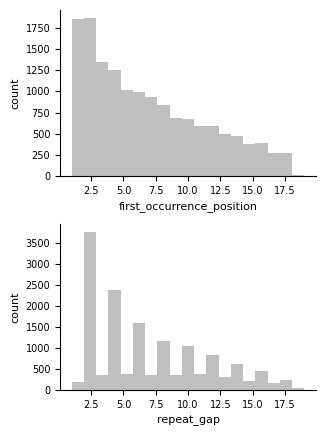

In [4]:
fig, axes = plt.subplots(2, 1, figsize=FIGSIZE_2PANEL)
axes[0].hist(d["first_occurrence_position"], bins=19, color="0.75", edgecolor="none")
axes[0].set_xlabel("first_occurrence_position")
axes[0].set_ylabel("count")
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].hist(d["repeat_gap"], bins=19, color="0.75", edgecolor="none")
axes[1].set_xlabel("repeat_gap")
axes[1].set_ylabel("count")
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
fig.savefig("../results/figures/real_data_position_gap_histograms.pdf")
plt.show()

## Correlations: real_skip and evaluation against position, gap, and first-occurrence

`session_position` here is the REPEAT's own absolute position in the session (as in the
earlier notebook); `first_occurrence_position` and `repeat_gap` are the two new tracked
variables.

In [5]:
rows = []
for col in ["session_position", "first_occurrence_position", "repeat_gap"]:
    rows.append({
        "variable": col,
        "corr_with_real_skip": d[col].corr(d["real_skip"]),
        "corr_with_evaluation": d[col].corr(d["evaluation"]),
    })
pd.DataFrame(rows)

,variable,corr_with_real_skip,corr_with_evaluation
0,session_position,0.007953,0.007366
1,first_occurrence_position,0.051051,0.046601
2,repeat_gap,-0.045158,-0.041117


## Binned skip rate vs. repeat_gap and first_occurrence_position

Same binned-with-95%-CI treatment used throughout the other notebook, applied to the two new
tracked variables instead of `evaluation`.

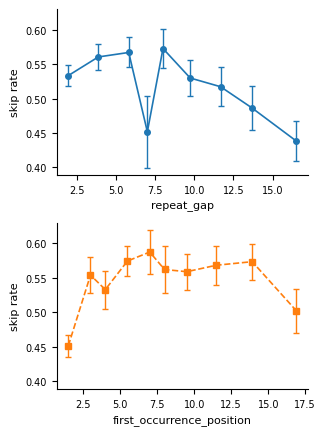

In [6]:
def binned_skip_rate(frame, value_col, num_bins=NUM_BINS):
    frame = frame.copy()
    frame["_bin"] = pd.qcut(frame[value_col], q=num_bins, duplicates="drop")
    g = frame.groupby("_bin", observed=True).agg(
        bin_mean=(value_col, "mean"), skip_rate=("real_skip", "mean"),
        n=("real_skip", "size")).reset_index()
    g["ci95"] = 1.96 * np.sqrt(g["skip_rate"] * (1 - g["skip_rate"]) / g["n"])
    return g

binned_gap = binned_skip_rate(d, "repeat_gap")
binned_first_pos = binned_skip_rate(d, "first_occurrence_position")

fig, axes = plt.subplots(2, 1, figsize=FIGSIZE_2PANEL, sharey=True)

axes[0].errorbar(binned_gap["bin_mean"], binned_gap["skip_rate"], yerr=binned_gap["ci95"],
                  fmt="o-", color="tab:blue", ecolor="tab:blue", elinewidth=1, capsize=2,
                  markersize=4, linewidth=1.2)
axes[0].set_xlabel("repeat_gap")
axes[0].set_ylabel("skip rate")
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].errorbar(binned_first_pos["bin_mean"], binned_first_pos["skip_rate"],
                  yerr=binned_first_pos["ci95"], fmt="s--", color="tab:orange", ecolor="tab:orange",
                  elinewidth=1, capsize=2, markersize=4, linewidth=1.2)
axes[1].set_xlabel("first_occurrence_position")
axes[1].set_ylabel("skip rate")
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
fig.savefig("../results/figures/real_data_skip_rate_vs_gap_and_position.pdf")
plt.show()

## Binned skip rate vs. evaluation (replication check)

Same style as the original single-pass analysis, for direct comparison against that earlier
result now that the position/gap restriction has been dropped.

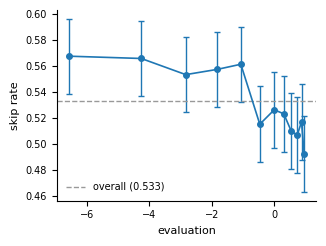

In [7]:
lo, hi = d["evaluation"].quantile([0.05, 0.95])
d_mid = d[(d["evaluation"] >= lo) & (d["evaluation"] <= hi)]
binned_eval = binned_skip_rate(d_mid, "evaluation")

fig, ax = plt.subplots(figsize=FIGSIZE_1PANEL)
ax.errorbar(binned_eval["bin_mean"], binned_eval["skip_rate"], yerr=binned_eval["ci95"],
            fmt="o-", color="tab:blue", ecolor="tab:blue", elinewidth=1, capsize=2,
            markersize=4, linewidth=1.2)
ax.axhline(d_mid["real_skip"].mean(), color="0.6", linewidth=1, linestyle="--",
           label=f"overall ({d_mid['real_skip'].mean():.3f})")
ax.set_xlabel("evaluation")
ax.set_ylabel("skip rate")
ax.legend(frameon=False, loc="best")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
fig.savefig("../results/figures/real_data_skip_rate_vs_evaluation.pdf")
plt.show()